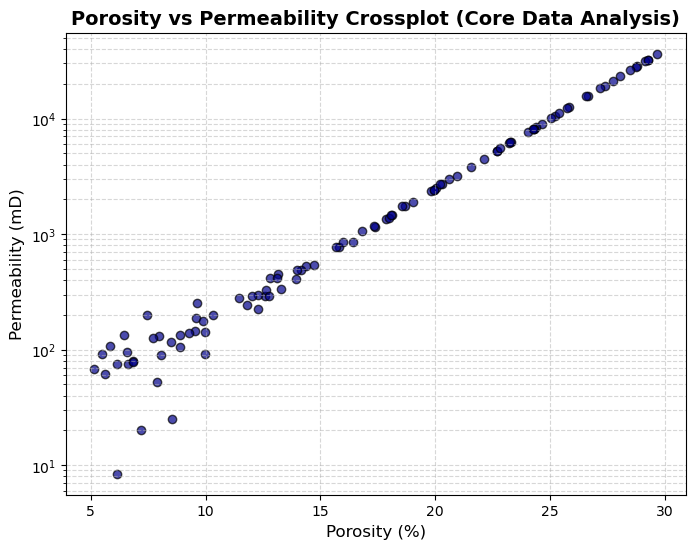

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. توليد بيانات افتراضية لـ 100 عينة صخرية (المسامية بين 5% و 30%)
np.random.seed(42)
porosity = np.random.uniform(0.05, 0.30, 100)

# 2. حساب النفاذية بناءً على معادلة فيزيائية تجريبية مع إضافة بعض العشوائية (Noise)
# نستخدم الدالة الأسية لأن النفاذية تتغير أسيّاً مع المسامية كما يذكر كتاب Tarek Ahmed
permeability = 10**(1 + 12 * porosity) + np.random.normal(0, 50, 100)
permeability = np.clip(permeability, 0.1, None) # منع القيم السالبة

# 3. رسم العلاقة البيانية (Crossplot)
plt.figure(figsize=(8, 6))
plt.scatter(porosity * 100, permeability, color='darkblue', alpha=0.7, edgecolors='k')

# إضافة التفاصيل الهندسية على الرسم
plt.title('Porosity vs Permeability Crossplot (Core Data Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Porosity (%)', fontsize=12)
plt.ylabel('Permeability (mD)', fontsize=12)
plt.yscale('log') # تحويل المحور العمودي إلى مقياس لوغاريتمي
plt.grid(True, which="both", ls="--", alpha=0.5)

# عرض الرسم
plt.show()

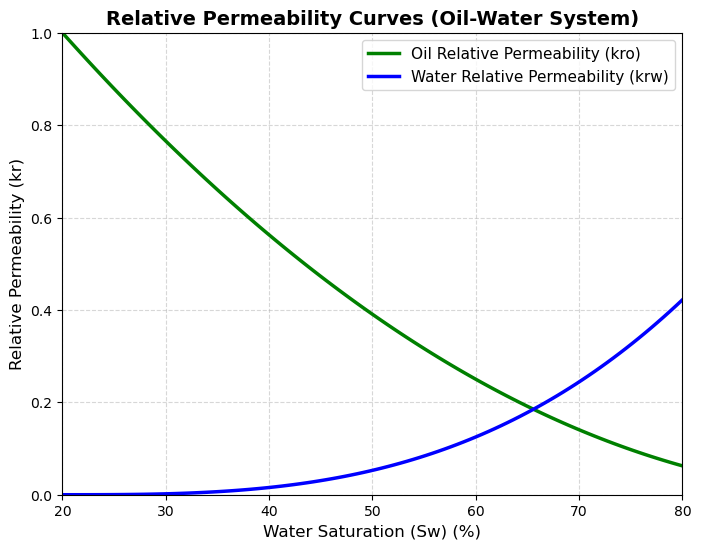

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. توليد قيم لتشبع الماء من 20% إلى 80%
sw = np.linspace(0.2, 0.8, 100)

# 2. حساب النفاذية النسبية للماء (krw) وللنفط (kro) بناءً على معادلات Corey الكلاسيكية
# كلما زاد الماء، زادت نفاذيته وقاطعت نفاذية النفط التي تنخفض
krw = ((sw - 0.2) / (1 - 0.2)) ** 3
kro = ((1 - sw) / (1 - 0.2)) ** 2

# 3. رسم كيرفات النفاذية النسبية
plt.figure(figsize=(8, 6))
plt.plot(sw * 100, kro, label='Oil Relative Permeability (kro)', color='green', linewidth=2.5)
plt.plot(sw * 100, krw, label='Water Relative Permeability (krw)', color='blue', linewidth=2.5)

# إضافة التفاصيل الهندسية
plt.title('Relative Permeability Curves (Oil-Water System)', fontsize=14, fontweight='bold')
plt.xlabel('Water Saturation (Sw) (%)', fontsize=12)
plt.ylabel('Relative Permeability (kr)', fontsize=12)
plt.xlim(20, 80)
plt.ylim(0, 1)
plt.grid(True, ls='--', alpha=0.5)
plt.legend(fontsize=11)

# عرض الرسم
plt.show()

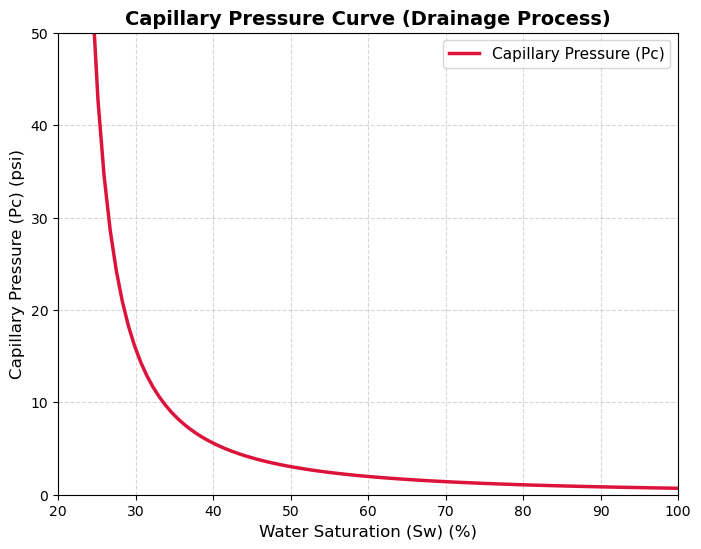

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. توليد قيم لتشبع الماء (Sw) من 22% إلى 100%
sw = np.linspace(0.22, 1.0, 100)

# 2. حساب الضغط الشعري (Pc) باستخدام معادلة تجريبية مبسطة
# كلما قل تشبع الماء (أي حاول النفط الدخول وطرد الماء)، يرتفع الضغط الشعري بقوة
pc = 0.5 / (sw - 0.2) ** 1.5

# 3. رسم منحنى الضغط الشعري
plt.figure(figsize=(8, 6))
plt.plot(sw * 100, pc, color='crimson', linewidth=2.5, label='Capillary Pressure (Pc)')

# إضافة التفاصيل الهندسية على الرسم
plt.title('Capillary Pressure Curve (Drainage Process)', fontsize=14, fontweight='bold')
plt.xlabel('Water Saturation (Sw) (%)', fontsize=12)
plt.ylabel('Capillary Pressure (Pc) (psi)', fontsize=12)
plt.xlim(20, 100)
plt.ylim(0, 50)
plt.grid(True, ls='--', alpha=0.5)
plt.legend(fontsize=11)

# عرض الرسم
plt.show()

In [1]:
import pandas as pd

# 1. بناء قاعدة بيانات حقل نفطي (4 آبار مع المسامية، النفاذية، ومعدل الإنتاج اليومي)
field_data = {
    'Well_Name': ['Well-A', 'Well-B', 'Well-C', 'Well-D'],
    'Porosity_%': [12.5, 24.0, 8.2, 19.5],
    'Permeability_mD': [150, 2500, 12, 680],
    'Oil_Production_BPD': [1200, 4500, 150, 2800], # BPD = برميل في اليوم
    'Water_Cut_%': [5, 45, 80, 12] # نسبة الماء المصاحب للإنتاج
}

# 2. تحويل القاموس إلى جدول Pandas DataFrame
df = pd.DataFrame(field_data)

# 3. عرض الجدول بالكامل بتنسيق احترافي
print("--- جدول بيانات الآبار بالكامل ---")
display(df)

# 4. حساب الإحصاءات الأساسية للحقل بضغطة زر واحدة!
print("\n--- التلخيص الإحصائي للحقل النفطي ---")
display(df.describe())

--- جدول بيانات الآبار بالكامل ---


,Well_Name,Porosity_%,Permeability_mD,Oil_Production_BPD,Water_Cut_%
0,Well-A,12.5,150,1200,5
1,Well-B,24.0,2500,4500,45
2,Well-C,8.2,12,150,80
3,Well-D,19.5,680,2800,12



--- التلخيص الإحصائي للحقل النفطي ---


,Porosity_%,Permeability_mD,Oil_Production_BPD,Water_Cut_%
count,4.000000,4.000000,4.000000,4.000000
mean,16.050000,835.500000,2162.500000,35.500000
std,7.055258,1146.415137,1901.479687,34.414144
min,8.200000,12.000000,150.000000,5.000000
25%,11.425000,115.500000,937.500000,10.250000
50%,16.000000,415.000000,2000.000000,28.500000
75%,20.625000,1135.000000,3225.000000,53.750000
max,24.000000,2500.000000,4500.000000,80.000000


In [2]:
# 1. تصفية الآبار التي نفاذيتها أعلى من 500 ميلي دارسي وبنفس الوقت نسبة الماء فيها أقل من 20%
high_perf_wells = df[(df['Permeability_mD'] > 500) & (df['Water_Cut_%'] < 20)]

print("--- الآبار ذات الأداء العالي والمياه المنخفضة ---")
display(high_perf_wells)

# 2. حساب بئر بطل الحقل (الأعلى إنتاجاً للنفط)
best_well = df[df['Oil_Production_BPD'] == df['Oil_Production_BPD'].max()]

print("\n--- البئر الأعلى إنتاجاً في الحقل ---")
display(best_well)

--- الآبار ذات الأداء العالي والمياه المنخفضة ---


,Well_Name,Porosity_%,Permeability_mD,Oil_Production_BPD,Water_Cut_%
3,Well-D,19.5,680,2800,12



--- البئر الأعلى إنتاجاً في الحقل ---


,Well_Name,Porosity_%,Permeability_mD,Oil_Production_BPD,Water_Cut_%
1,Well-B,24.0,2500,4500,45


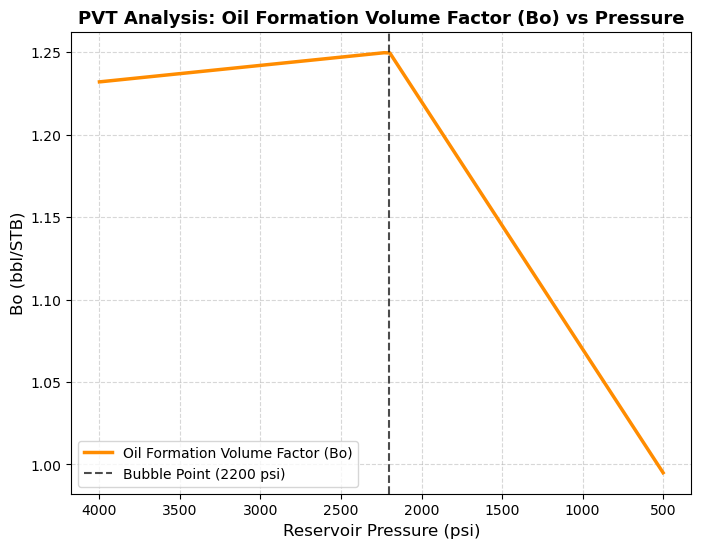

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. توليد قيم هبوط ضغط المكمن من 4000 إلى 500 psi
pressure = np.linspace(4000, 500, 100)
bubble_point = 2200 # نفترض أن ضغط الفقاعة هو 2200 psi

# 2. حساب معامل الحجم Bo بناءً على سلوك الموائع الشهير
bo = []
for p in pressure:
    if p >= bubble_point:
        # فوق ضغط الفقاعة: النفط ينضغط قليلاً جداً فيكاد حجمه يكون ثابتاً أو يرتفع طفيفاً
        bo.append(1.25 - (p - bubble_point) * 0.00001)
    else:
        # تحت ضغط الفقاعة: الغاز يهرب والنفط ينكمش بسرعة هائلة!
        bo.append(1.25 - (bubble_point - p) * 0.00015)

# 3. رسم منحنى الـ PVT (Pressure vs Bo)
plt.figure(figsize=(8, 6))
plt.plot(pressure, bo, color='darkorange', linewidth=2.5, label='Oil Formation Volume Factor (Bo)')
plt.axvline(x=bubble_point, color='black', linestyle='--', alpha=0.7, label=f'Bubble Point ({bubble_point} psi)')

# إضافة التفاصيل الهندسية
plt.title('PVT Analysis: Oil Formation Volume Factor (Bo) vs Pressure', fontsize=13, fontweight='bold')
plt.xlabel('Reservoir Pressure (psi)', fontsize=12)
plt.ylabel('Bo (bbl/STB)', fontsize=12)
plt.gca().invert_xaxis() # قلب المحور الأفقي لأن الضغط يهبط بمرور الوقت
plt.grid(True, ls='--', alpha=0.5)
plt.legend(fontsize=10)

# عرض الرسم
plt.show()

In [7]:
# حساب النفط الأصلي في المكمن (STOIIP) باستخدام المتغيرات الهندسيّة الأساسية

# 1. إدخال البيانات الجيوفيزيائية للحقل
area = 5000         # مساحة الحقل بالفدان (Acres)
thickness = 45      # سمك الطبقة النفطية بالقدم (Feet)
porosity = 0.18     # المسامية المتوسطة للحقل (18%)
swi = 0.25          # تشبع الماء الابتدائي (25%)

# 2. جلب قيمة Bo عند الضغط الابتدائي للمكمن من تجربة الـ PVT السابقة
bo_initial = 1.24   # برميل مكمني لكل برميل سطحي

# 3. تطبيق المعادلة الهندسية الكلاسيكية لحساب الحجم (بالملايين)
# الرقم 7758 هو عامل تحويل هندسي ثابت لتحويل (Acre-feet) إلى براميل
stoiip = (7758 * area * thickness * porosity * (1 - swi)) / bo_initial
stoiip_million = stoiip / 1000000

print(f"--- نتائج حسابات حجم المكمن ---")
print(f"إجمالي النفط الأصلي الموجود في باطن الأرض: {stoiip_million:.2f} مليون برميل سطحي (MMSTB)")

--- نتائج حسابات حجم المكمن ---
إجمالي النفط الأصلي الموجود في باطن الأرض: 190.04 مليون برميل سطحي (MMSTB)


In [8]:
# حساب النفط القابل للاستخراج (Reserves) بناءً على نوع آلية الدفع

stoiip_input = 190.5  # حجم حقلنا السابق بالملايين (MMSTB)

# 1. تحديد نسب الاستخلاص المتوسطة لكل آلية دفع
drive_mechanisms = {
    'Solution Gas Drive': 0.12,  # 12% استخلاص
    'Gas Cap Drive': 0.25,       # 25% استخلاص
    'Water Drive': 0.45          # 45% استخلاص
}

print(f"--- تقرير جدوى الإنتاج المتوقع للحقل ({stoiip_input} MMSTB) --- \n")

# 2. حساب الكمية القابلة للإنتاج (قابل للاستخراج تجارياً) لكل نوع
for drive, rf in drive_mechanisms.items():
    producable_oil = stoiip_input * rf
    lost_oil = stoiip_input * (1 - rf)
    
    print(f"📌 في حال كان المكمن يعمل بـ [{drive}]:")
    print(f"   - معامل الاستخلاص المتوقع: {rf*100}%")
    print(f"   - الكمية التي سنربحها وننتجها: {producable_oil:.2f} مليون برميل (MMSTB)")
    print(f"   - النفط المهدر والمحبوس للأبد: {lost_oil:.2f} مليون برميل (MMSTB)")
    print("-" * 50)

--- تقرير جدوى الإنتاج المتوقع للحقل (190.5 MMSTB) --- 

📌 في حال كان المكمن يعمل بـ [Solution Gas Drive]:
   - معامل الاستخلاص المتوقع: 12.0%
   - الكمية التي سنربحها وننتجها: 22.86 مليون برميل (MMSTB)
   - النفط المهدر والمحبوس للأبد: 167.64 مليون برميل (MMSTB)
--------------------------------------------------
📌 في حال كان المكمن يعمل بـ [Gas Cap Drive]:
   - معامل الاستخلاص المتوقع: 25.0%
   - الكمية التي سنربحها وننتجها: 47.62 مليون برميل (MMSTB)
   - النفط المهدر والمحبوس للأبد: 142.88 مليون برميل (MMSTB)
--------------------------------------------------
📌 في حال كان المكمن يعمل بـ [Water Drive]:
   - معامل الاستخلاص المتوقع: 45.0%
   - الكمية التي سنربحها وننتجها: 85.73 مليون برميل (MMSTB)
   - النفط المهدر والمحبوس للأبد: 104.78 مليون برميل (MMSTB)
--------------------------------------------------


In [9]:
import sqlite3
import pandas as pd

# 1. إنشاء قاعدة بيانات وهمية في الذاكرة والاتصال بها
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 2. بناء جدول نفطي باستخدام لغة SQL (إنشاء جدول الآبار)
cursor.execute('''
CREATE TABLE IF NOT EXISTS oil_field_production (
    well_id TEXT,
    production_date TEXT,
    oil_bpd REAL,
    choke_size TEXT
)
''')

# 3. حشو الجدول ببيانات إنتاج تاريخية لبئرين
production_history = [
    ('Well-01', '2026-06-01', 1500, '32/64'),
    ('Well-01', '2026-06-02', 1480, '32/64'),
    ('Well-02', '2026-06-01', 4100, '48/64'),
    ('Well-02', '2026-06-02', 4050, '48/64'),
    ('Well-01', '2026-06-03', 1450, '32/64')
]
cursor.executemany('INSERT INTO oil_field_production VALUES (?,?,?,?)', production_history)
conn.commit()

# =================================================================
# 🎯 هنا يبدأ سحر الـ SQL الفعلي!
# سنكتب استعلاماً يجلب فقط بيانات البئر "Well-01" المرتبة تاريخياً
sql_query = """
SELECT well_id, production_date, oil_bpd 
FROM oil_field_production 
WHERE well_id = 'Well-01'
ORDER BY production_date ASC;
"""
# =================================================================

# 4. تشغيل استعلام SQL وعرض النتيجة كجدول Pandas أنيق
df_sql = pd.read_sql_query(sql_query, conn)
print("--- النتيجة المستخرجة من سيرفر قاعدة البيانات باستخدام SQL ---")
display(df_sql)

# إغلاق الاتصال
conn.close()

--- النتيجة المستخرجة من سيرفر قاعدة البيانات باستخدام SQL ---


,well_id,production_date,oil_bpd
0,Well-01,2026-06-01,1500.0
1,Well-01,2026-06-02,1480.0
2,Well-01,2026-06-03,1450.0
